### Importing Required Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import confusion_matrix, classification_report,accuracy_score

### Importing and Reading Dataset

In [24]:
data = pd.read_csv('../Dataset/Crop_recommendation.csv')
data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [25]:
#Renaming Columns for better understanding
new_names = {
    'N': 'Nitrogen',
    'P': 'Phosphorus',
    'K': 'Potassium',
    'temperature': 'Temperature',
    'humidity': 'Humidity',
    'ph': 'pH Level',
    'rainfall': 'Rainfall',
    'label': 'Crop'
}
data = data.rename(columns=new_names)

### Visualization and Analysis of Data

#### Univariate Analysis

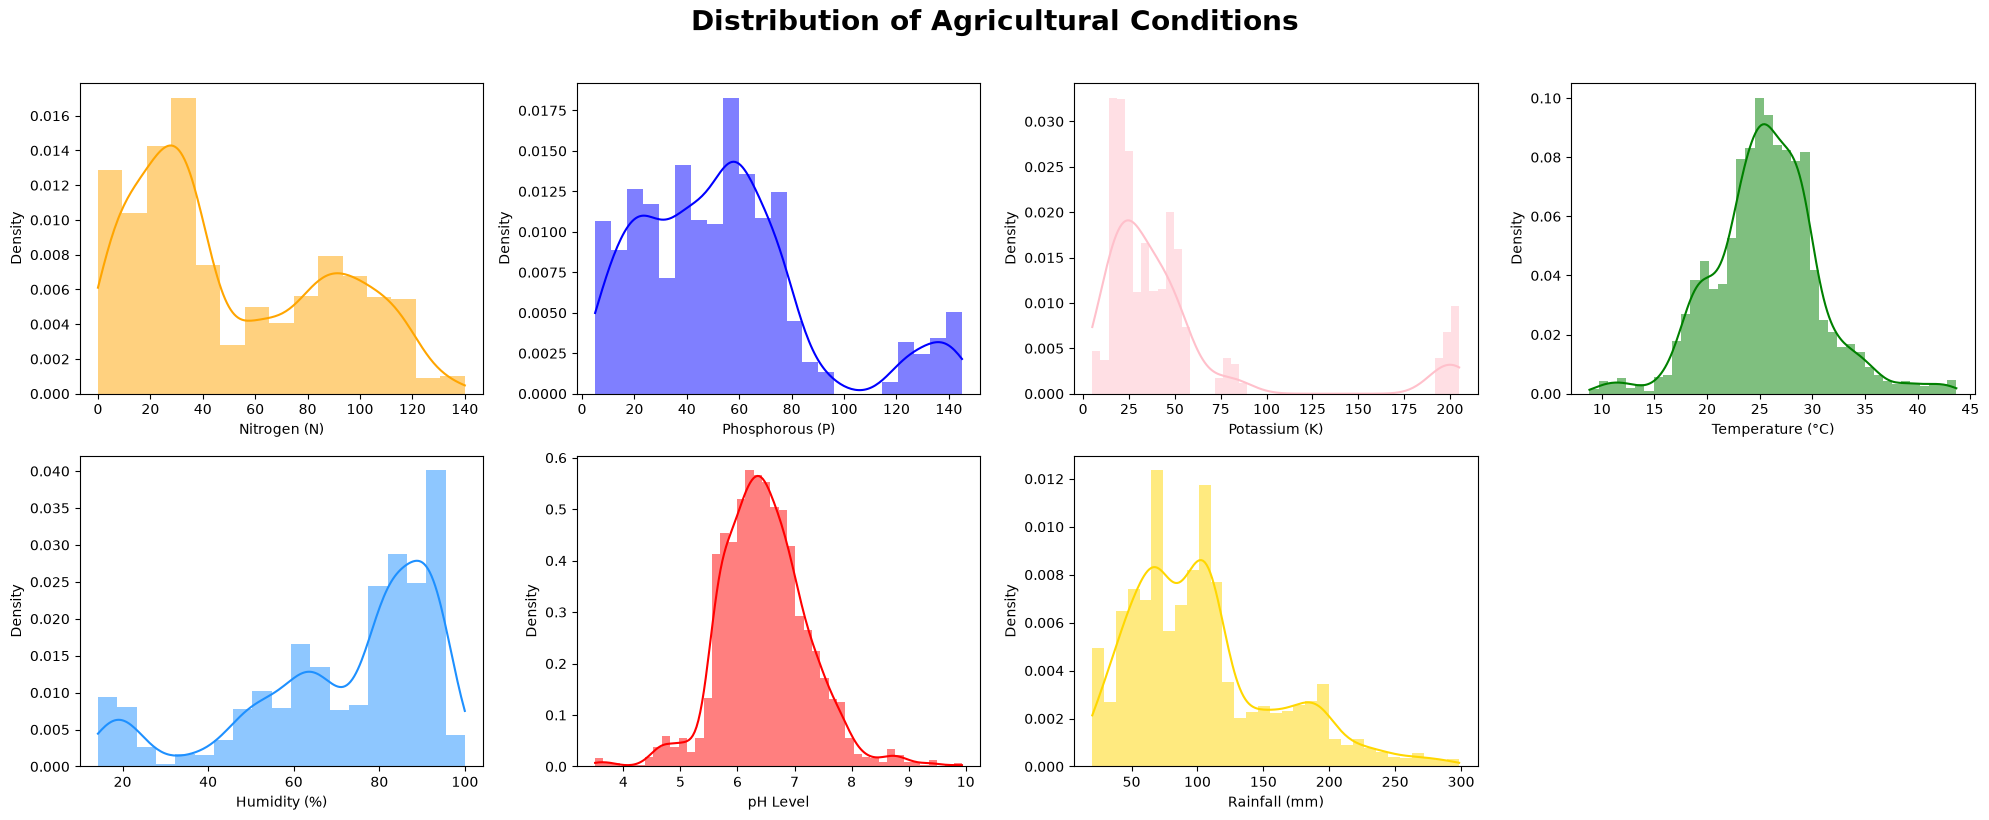

In [26]:
#Plotting the Distplot
features = data.drop(['Crop'],axis=1).columns
labels = [
    'Nitrogen (N)', 'Phosphorous (P)', 'Potassium (K)', 
    'Temperature (°C)', 'Humidity (%)', 'pH Level', 'Rainfall (mm)'
]
colors = ['orange', 'blue', 'pink', 'green', 'dodgerblue', 'red', 'gold']

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten() 


for i in range(len(features)):
    sns.histplot(data[features[i]],ax=axes[i],color=colors[i],stat='density',kde=True,edgecolor=None)
    axes[i].set_xlabel(labels[i])
axes[7].set_visible(False)

plt.suptitle('Distribution of Agricultural Conditions', fontsize=20, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

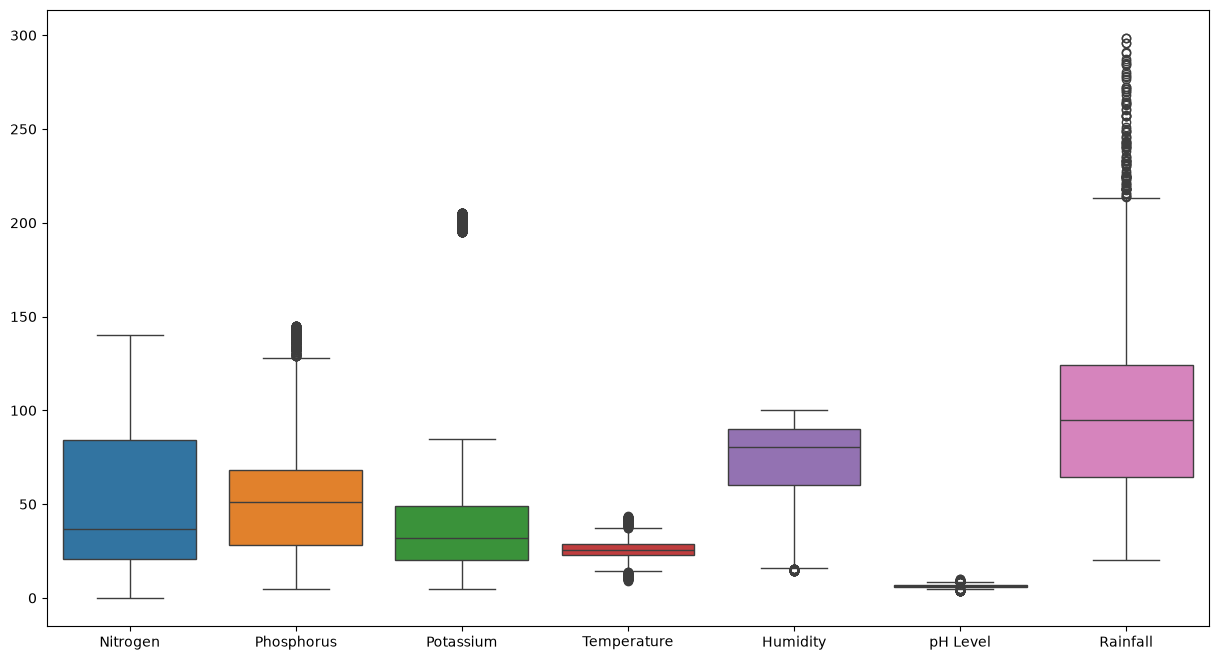

In [27]:
#Plotting Box Plot to visualize outliers

plt.figure(figsize=(15,8))
sns.boxplot(data)
plt.show()

#### Bivariate Analysis

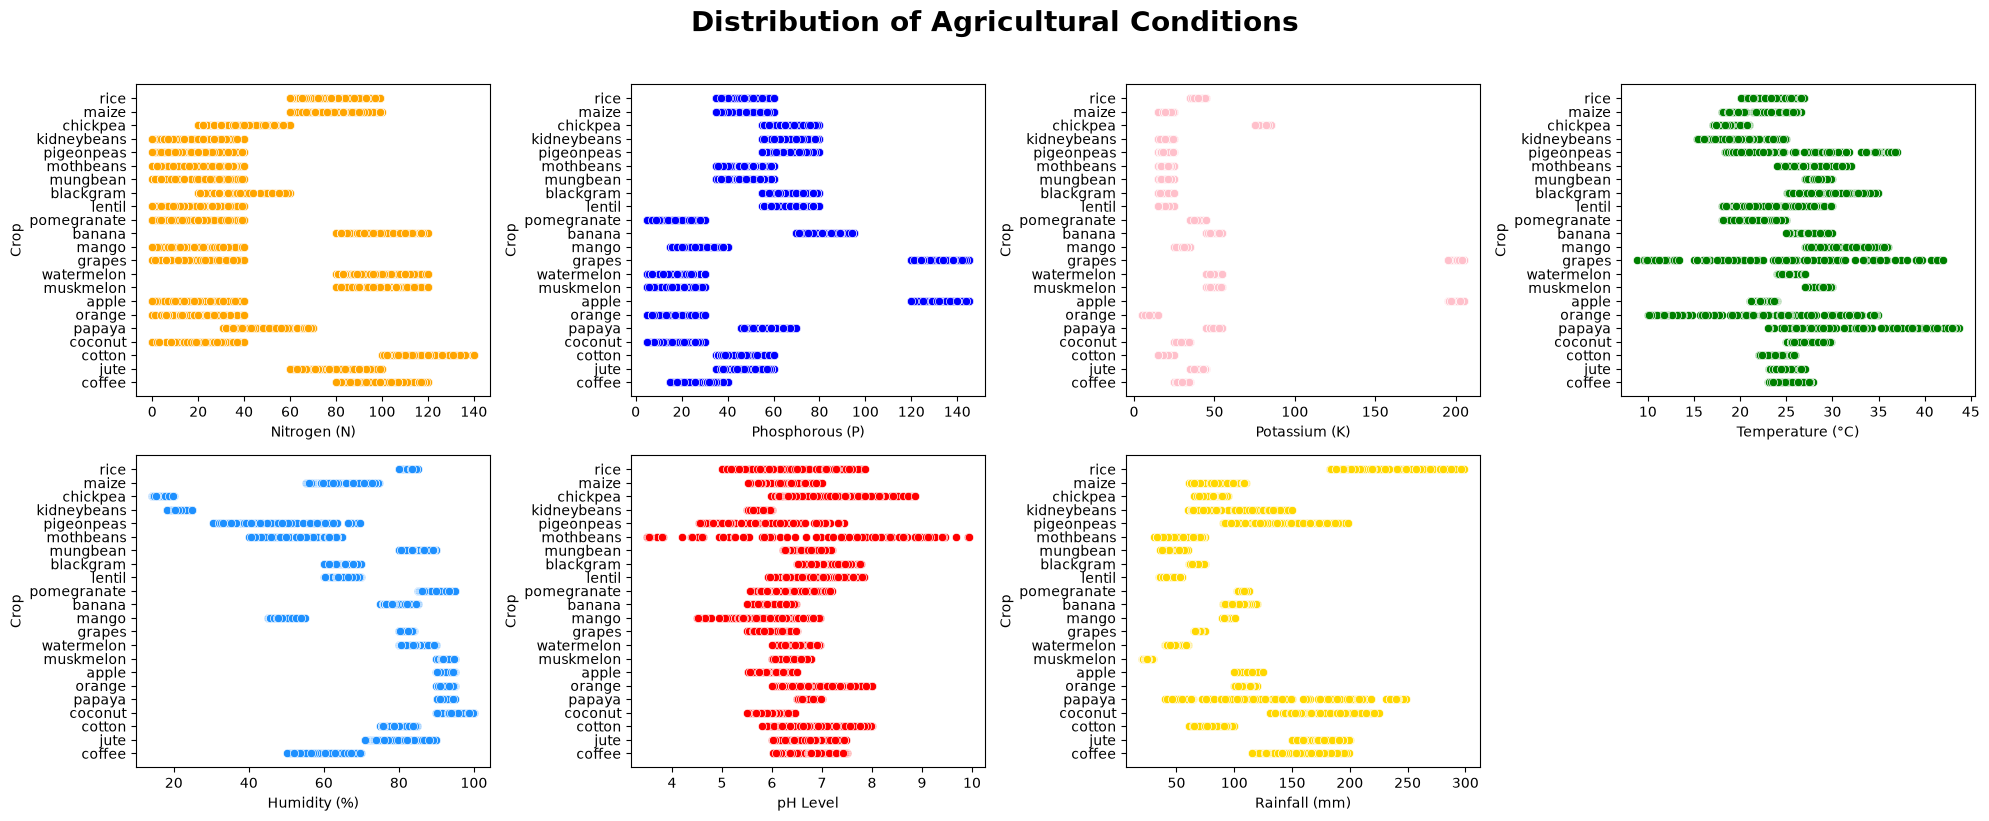

In [28]:
#Plotting the Scatter Plot
features = data.drop(['Crop'],axis=1).columns
labels = [
    'Nitrogen (N)', 'Phosphorous (P)', 'Potassium (K)', 
    'Temperature (°C)', 'Humidity (%)', 'pH Level', 'Rainfall (mm)'
]
colors = ['orange', 'blue', 'pink', 'green', 'dodgerblue', 'red', 'gold'] # Changed yellow to gold for visibility

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten() 


for i in range(len(features)):
    sns.scatterplot(x=data[features[i]],y=data['Crop'],ax=axes[i],color=colors[i])
    axes[i].set_xlabel(labels[i])
axes[7].set_visible(False)

plt.suptitle('Distribution of Agricultural Conditions', fontsize=20, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()

#### Multivariate Analysis

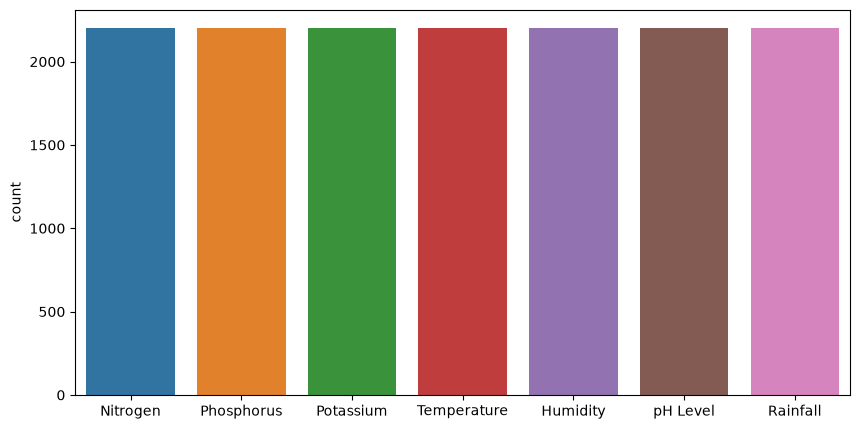

In [29]:
#Plotting Count plot

plt.figure(figsize=(10,5))
sns.countplot(data)
plt.show()

In [30]:
#Descriptive Analysis

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nitrogen     2200 non-null   int64  
 1   Phosphorus   2200 non-null   int64  
 2   Potassium    2200 non-null   int64  
 3   Temperature  2200 non-null   float64
 4   Humidity     2200 non-null   float64
 5   pH Level     2200 non-null   float64
 6   Rainfall     2200 non-null   float64
 7   Crop         2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB


### Data Preprocessing

#### Handling Null Values

In [31]:
#Counting no of null values in each columns
data.isnull().sum()

Nitrogen       0
Phosphorus     0
Potassium      0
Temperature    0
Humidity       0
pH Level       0
Rainfall       0
Crop           0
dtype: int64

In [32]:
data.shape

(2200, 8)

#### Handling Outliers

In [33]:
#Phosphorous
Q1 = data['Phosphorus'].quantile(0.25)
Q3 = data['Phosphorus'].quantile(0.75)

IQR = Q3 - Q1

filter = (data['Phosphorus'] >= Q1 - 1.5*IQR) & (data['Phosphorus'] <= Q3 + 1.5*IQR)
data = data.loc[filter]

In [34]:
#Potassium
Q1 = data['Potassium'].quantile(0.25)
Q3 = data['Potassium'].quantile(0.75)

IQR = Q3 - Q1

filter = (data['Potassium'] >= Q1 - 1.5*IQR) & (data['Potassium'] <= Q3 + 1.5*IQR)
data = data.loc[filter]

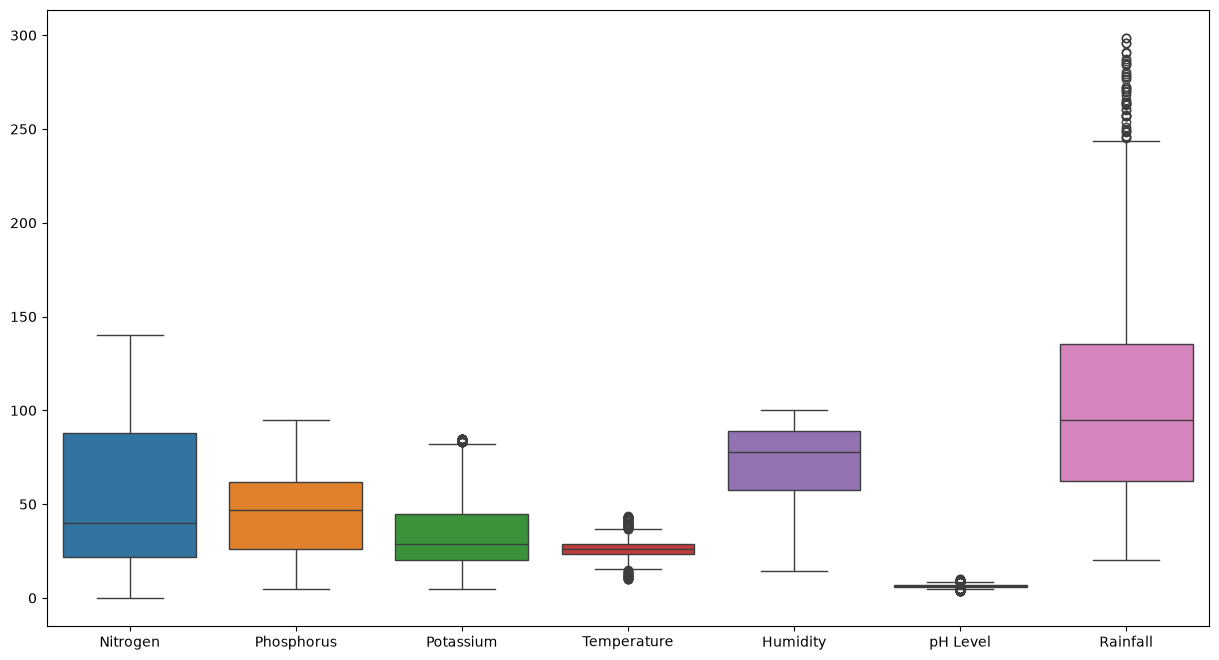

In [35]:
#Plotting Box Plot to see changes

plt.figure(figsize=(15,8))
sns.boxplot(data)
plt.show()

#### Extracting Seasonal Crops

In [36]:
print("Summer crops")
print(list(data[(data['Temperature']>30) & (data['Humidity']>50)] ['Crop'].unique()))
print("------------------------------------------------------------------------")
print("Winter crops")
print(list(data[(data['Temperature']<20) & (data['Humidity']>30)] ['Crop'].unique()))
print("------------------------------------------------------------------------")
print("Rainy crops")
print(list(data[(data['Rainfall']>200) & (data['Humidity']>50)] ['Crop'].unique()))
print("------------------------------------------------------------------------")

Summer crops
['pigeonpeas', 'mothbeans', 'blackgram', 'mango', 'orange', 'papaya']
------------------------------------------------------------------------
Winter crops
['maize', 'pigeonpeas', 'lentil', 'pomegranate', 'orange']
------------------------------------------------------------------------
Rainy crops
['rice', 'papaya', 'coconut']
------------------------------------------------------------------------


#### Splitting Data into Train and Test Sets

In [37]:
x = data.drop(['Crop'],axis=1)
y = data['Crop']

print('X Shape:',x.shape)
print('Y Shape:',y.shape)

X Shape: (2000, 7)
Y Shape: (2000,)


In [38]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=0,test_size=0.2)
print('X Train Shape:',x_train.shape)
print('Y Train Shape:',y_train.shape)
print('X Test Shape:',x_test.shape)
print('Y Test Shape:',y_test.shape)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

X Train Shape: (1600, 7)
Y Train Shape: (1600,)
X Test Shape: (400, 7)
Y Test Shape: (400,)


### Model Building

#### K Means Clustering

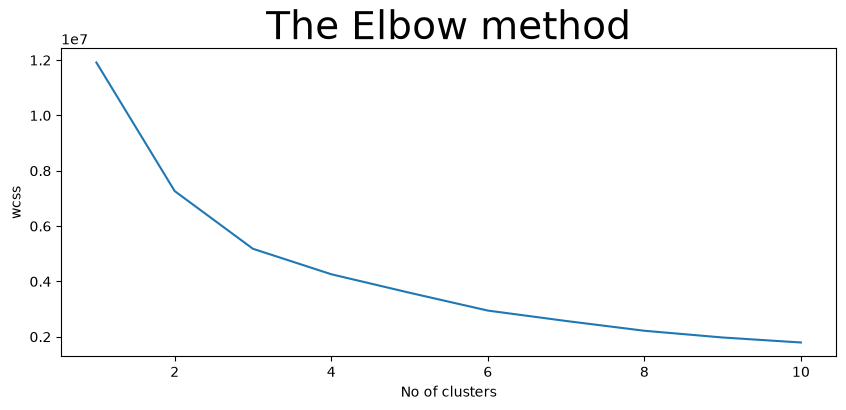

In [39]:
#el-bow method used to find out no of clusters and determine the optimum number of clusters within the dataset.
plt.rcParams['figure.figsize']=(10,4)
wcss=[]
for i in range(1,11):
    km = KMeans(n_clusters=i,init="k-means++", max_iter=300,n_init=10, random_state=0)
    km.fit(x)
    wcss.append(km.inertia_)

plt.plot(range (1,11), wcss)
plt.title("The Elbow method", fontsize=28)
plt.xlabel("No of clusters")
plt.ylabel("wcss")
plt.show()

In [40]:
km=KMeans(n_clusters = 4, init="k-means++", max_iter=300,n_init=10, random_state=0)
y_means=km.fit_predict(x)
a=data['Crop']
y_means=pd.DataFrame(y_means)
z=pd.concat([y_means,a], axis=1)
z=z.rename(columns={0:"cluster"})

print("Crops in First cluster:", list(z[z['cluster']==0] ['Crop'].unique()))
print("____________________________________________________________________")
print("Crops in Second cluster:", list(z[z['cluster']==1]['Crop'].unique()))
print("____________________________________________________________________")
print("Crops in Third cluster:", list(z[z['cluster']==2]['Crop'].unique()))
print("____________________________________________________________________")
print("Crops in Fourth cluster:", list(z[z['cluster']==3]['Crop'].unique()))


Crops in First cluster: ['maize', 'banana', nan, 'watermelon', 'papaya', 'cotton']
____________________________________________________________________
Crops in Second cluster: ['maize', 'kidneybeans', 'pigeonpeas', 'pomegranate', 'mango', 'muskmelon', nan, 'orange', 'cotton']
____________________________________________________________________
Crops in Third cluster: ['maize', 'chickpea', 'kidneybeans', 'pigeonpeas', 'mothbeans', 'mungbean', 'blackgram', 'lentil', 'mango', nan]
____________________________________________________________________
Crops in Fourth cluster: ['rice', 'pigeonpeas', nan, 'orange', 'coconut', 'cotton']


#### Logistic Regression

In [41]:
lr_model = LogisticRegression()
lr_model.fit(x_train_scaled,y_train)
y_pred = lr_model.predict(x_test_scaled)

print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

      banana       1.00      1.00      1.00        18
   blackgram       0.95      0.95      0.95        21
    chickpea       1.00      1.00      1.00        24
     coconut       1.00      1.00      1.00        21
      coffee       1.00      1.00      1.00        21
      cotton       1.00      0.96      0.98        24
        jute       1.00      0.85      0.92        20
 kidneybeans       1.00      0.95      0.97        19
      lentil       1.00      0.95      0.97        19
       maize       0.94      1.00      0.97        17
       mango       1.00      1.00      1.00        22
   mothbeans       0.82      1.00      0.90        18
    mungbean       1.00      1.00      1.00        16
   muskmelon       1.00      1.00      1.00        22
      orange       1.00      1.00      1.00        17
      papaya       1.00      1.00      1.00        17
  pigeonpeas       0.95      0.86      0.90        21
 pomegranate       1.00    

#### Decision Tree Classifier

In [42]:
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=42)

dt_model.fit(x_train, y_train)

dt_predictions = dt_model.predict(x_test)

dt_accuracy = accuracy_score(y_test, dt_predictions)
print(f"Decision Tree Accuracy: {dt_accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, dt_predictions))

Decision Tree Accuracy: 98.00%

Classification Report:
              precision    recall  f1-score   support

      banana       0.90      1.00      0.95        18
   blackgram       0.95      0.90      0.93        21
    chickpea       1.00      1.00      1.00        24
     coconut       1.00      1.00      1.00        21
      coffee       1.00      1.00      1.00        21
      cotton       1.00      1.00      1.00        23
        jute       0.89      1.00      0.94        17
 kidneybeans       1.00      1.00      1.00        18
      lentil       1.00      0.94      0.97        18
       maize       0.95      1.00      0.97        18
       mango       1.00      1.00      1.00        22
   mothbeans       0.91      0.95      0.93        22
    mungbean       1.00      1.00      1.00        16
   muskmelon       1.00      1.00      1.00        22
      orange       1.00      1.00      1.00        17
      papaya       1.00      0.88      0.94        17
  pigeonpeas       1.00   

### Model Saving And Export

In [44]:
import pickle

with open('../Flask/crop_model.pkl', 'wb') as file:
    pickle.dump(lr_model, file)

# Save the Standard Scaler
with open('../Flask/scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print("Model and Scaler saved successfully!")

Model and Scaler saved successfully!
